This notebook sets the hexagonal grids for the park, that the later lidar analysis (and foliage analysis, but that's set up as hex polygons as opposed to centroids) use.

I've begun with a pretty extensive import list, but this will be whittled down as I iterate.

In [1]:
# Import required libraries
import laspy
import rasterio
from rasterio.transform import from_bounds
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile
from rasterio.warp import calculate_default_transform, reproject, Resampling
from scipy.interpolate import griddata
from scipy.ndimage import generic_filter
import pdal
import json
from pathlib import Path
import datetime

import rasterio
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile

import glob
import os

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union

In [41]:
from shapely.geometry import box

In [63]:
# for dev work

import sys
import importlib

# Add src to path (do this once at the top)
sys.path.insert(0, '../../src')

# Initial import
import park_vga

# After editing:
importlib.reload(park_vga.defining_grids)
importlib.reload(park_vga)

<module 'park_vga' from '/Users/maeve/Documents/park-vga/notebooks/modularising_the_approach/../../src/park_vga/__init__.py'>

In [64]:
park_vga.example()

hello world!
version 2


In [2]:
# park_gdf= gpd.read_file("../../processed_datasets/Leeds_Woodhouse_Moor_park_boundaries.geojson")
# lidar_dir= "../../example_datasets"
# OUTPUT_DIR = Path("../../outputs/method_03_hex")
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# # Analysis parameters
# GRID_SPACING = 10  # meters between analysis points
# OBSERVER_HEIGHT = 1.0  # meters (eye height)
# MAX_DISTANCE = 100  # maximum visibility distance in meters
# MIN_VEG_AREA = 2  # minimum vegetation polygon area in sq meters

# FILE_NAME = f"Woodhouse_Moor_{GRID_SPACING}_m_grid_hex_buffer"

In [3]:
# "Primary Name": "Woodhouse Moor",

In [4]:
# turning this into a function - will add to module under different name (without test_)

def test_load_data(boundaries_file, primary_name, buffer_distance):
    # Load park boundaries
    park_gdf = gpd.read_file(boundaries_file)
    
    # Filter for the specific park
    park_gdf = park_gdf[park_gdf['Primary Name'] == primary_name]
    
    # Create buffer around the park boundary
    park_gdf['geometry'] = park_gdf.geometry.buffer(buffer_distance)
    
    return park_gdf


In [5]:
boundaries_file = "../../example_datasets/Leeds_pp_or_g_cmb.geojson"
primary_name = "Woodhouse Moor"
buffer_distance = 20 # metres

In [15]:
# now doing it via the module function:

park_gdf = park_vga.load_data(boundaries_file, primary_name, buffer_distance)

In [19]:
park_gdf.columns

Index(['Name (OS)', 'Other name(s) (OS)', 'Type (OS)', 'OS ID', 'Name (OSM)',
       'Other name(s) (OSM)', 'Type (OSM)', 'OSM ID', 'flag', 'id',
       'Primary Name', 'Other Names', 'Merged Count', 'Total Area (m²)',
       'geometry'],
      dtype='str')

In [58]:
park_gdf.head()

,Name (OS),Other name(s) (OS),Type (OS),OS ID,Name (OSM),Other name(s) (OSM),Type (OSM),OSM ID,flag,id,Primary Name,Other Names,Merged Count,Total Area (m²),geometry
51,NaN,None,Public Park Or Garden,3D6C4AD7-033F-80C3-E063-8ECAA00A8EB3,NaN,NaN,NaN,4002489.0; 224962322.0,OS; OSM,LEEDS_6ddbccbe638c;LEEDS_9866db1f86cb;LEEDS_57...,Woodhouse Moor,Woodhouse Moor Park,3,219143.971209,"POLYGON ((428682.036 434968.572, 428682.682 43..."


EPSG:27700
Bufferred park area: 258751.54042094335
Original park area: 219143.971209261


<Axes: >

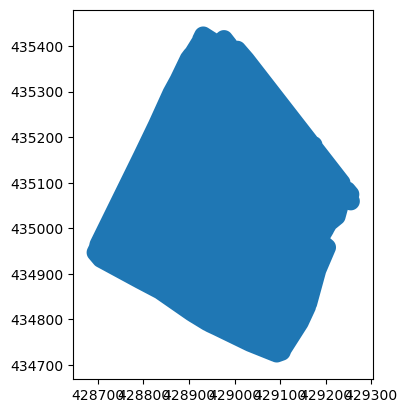

In [25]:
# check that it worked:
print(park_gdf.crs)
print("Bufferred park area:", park_gdf.geometry.iloc[0].area)
print("Original park area:", park_gdf['Total Area (m²)'].iloc[0])
park_gdf.plot()

In [50]:
# Calculate the bounding box and then find the appropriate lidar tile 

bbox_list = list(park_gdf.bounds.iloc[0])

In [51]:
bbox_list

[428675.24753552524, 434705.6015645066, 429274.64295245457, 435442.7927353812]

In [52]:
test_bbox = gpd.GeoSeries(box(*bbox_list), crs="EPSG:27700")

In [53]:
# test_bbox = park_gdf.envelope

In [ ]:
def test_easting_northing_to_os_grid(easting, northing, include_quadrant=False):
    """
    Convert easting/northing (British National grid - EPSG:27700) directly to OS grid reference.
    
    Parameters:
    -----------
    easting : float
        Easting in meters (EPSG:27700)
    northing : float
        Northing in meters (EPSG:27700)
    include_quadrant : bool
        If True, returns quadrant (ne, nw, se, sw). If False, returns basic 10km reference.
        
    Returns:
    --------
    str : OS grid reference (e.g., 'SD50' or 'SD50ne')
    """
    
    first_letters = ['S', 'T', 'N', 'O', 'H']
    second_letters = ['V', 'W', 'X', 'Y', 'Z',
                      'Q', 'R', 'S', 'T', 'U',
                      'L', 'M', 'N', 'O', 'P',
                      'F', 'G', 'H', 'J', 'K',
                      'A', 'B', 'C', 'D', 'E']
    
    e_500 = int(easting / 500000)
    n_500 = int(northing / 500000)
    e_100 = int((easting % 500000) / 100000)
    n_100 = int((northing % 500000) / 100000)
    
    try:
        first_letter = first_letters[n_500 * 2 + e_500]
        second_letter = second_letters[n_100 * 5 + e_100]
    except IndexError:
        return None
    
    e_within_100km = (easting % 100000) / 1000
    n_within_100km = (northing % 100000) / 1000
    e_10km = int(e_within_100km / 10)
    n_10km = int(n_within_100km / 10)
    
    grid_ref = f"{first_letter}{second_letter}{e_10km}{n_10km}"
    
    if include_quadrant:
        e_is_east = (e_within_100km % 10) >= 5
        n_is_north = (n_within_100km % 10) >= 5
        quadrant = ('ne' if e_is_east and n_is_north else
                   'se' if e_is_east else
                   'nw' if n_is_north else 'sw')
        grid_ref += quadrant
    
    return grid_ref

In [55]:
def test_get_tile_refs_from_bbox(bbox):
    # get the corner points of the bounding box
    corners = [bbox[0].exterior.coords[i] for i in range(4)]
    # print(corners) # for dev, but remove for scaling up.

    # convert each corner to a grid reference
    grid_refs = [test_easting_northing_to_os_grid(corner[1], corner[0], include_quadrant=True) for corner in corners]
    
    # return unique grid references
    return set(grid_refs)

In [56]:
test_grid_refs = test_get_tile_refs_from_bbox(test_bbox)

In [38]:
test_bbox

51    POLYGON ((428675.248 434705.602, 429274.643 43...
dtype: geometry

In [57]:
print(test_grid_refs)

{'SE32nw', 'SE32ne'}


In [61]:
def test_find_tiles(park_gdf, crs="EPSG:27700"):
    """From bounding park geometry, calculate bounding box and associated grid refs"""
    bbox_list = list(park_gdf.bounds.iloc[0])
    bbox = gpd.GeoSeries(box(*bbox_list), crs=crs)
    grid_refs = test_get_tile_refs_from_bbox(bbox)
    return set(grid_refs)

In [62]:
test_find_tiles(park_gdf)

{'SE32ne', 'SE32nw'}

In [65]:
park_vga.find_tiles(park_gdf)

{'SE32ne', 'SE32nw'}

Now we have to do a file path search and match the file path